In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from dotenv import load_dotenv 
from langchain_groq import ChatGroq
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
import os 


In [3]:

# 1. Setup Environment
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3.6-27b")



In [4]:

# 3. Define Tools
@tool 
def getweather(city: str) -> str:
    """get the weather of the city will i will provide to you"""
    return f"the weather of the {city} is 78 f"

@tool 
def pincode_db_q(query: str) -> str:
    """your db master and the expert now you need to arrange the get write the queries"""
    return query

tools_list = [getweather, pincode_db_q]

In [5]:

# 4. Bind Tools to LLM
T_llm = llm.bind_tools(tools_list)


In [6]:

# 5. Define Nodes
def bot_node(state: MessagesState):
    # LLM processes the conversation history and generates a response or tool call
    response = T_llm.invoke(state["messages"])
    return {"messages": [response]} 

# ToolNode automatically handles calling the functions we defined
tool_node = ToolNode(tools_list)

In [7]:

# 6. Build the Non-Reactive Graph
workflow = StateGraph(MessagesState)

# Add our two nodes
workflow.add_node("botnode", bot_node)
workflow.add_node("tools", tool_node) # Node must be named exactly "tools" for tools_condition to work

# Graph edges defining the flow
workflow.add_edge(START, "botnode")

# Conditional edge: If LLM outputs a tool call -> go to "tools". Otherwise -> END.
workflow.add_conditional_edges(
    "botnode",
    tools_condition
)


# === THE NON-REACTIVE PART ===
# After the tool runs, we go straight to END instead of looping back to "botnode"
workflow.add_edge("tools", END) 

# Compile the workflow
app = workflow.compile()


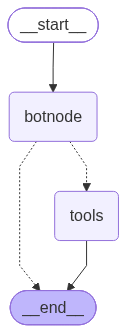

In [8]:


# Optional: Draw the graph to verify visually
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not draw graph: {e}")


In [ ]:
result = app.invoke({"messages": [("user", "What is the weather in Delhi?")]})

last_message = result["messages"][-1]
print(f"Type: {last_message.type}")
print(f"Content: {last_message.content}") 


Type: tool
Content: the weather of the Delhi is 78 f


In [ ]:
result = app.invoke({"messages": [("user", "how are u")]})

last_message = result["messages"][-1]
print(f"Type: {last_message.type}")
print(f"Content: {last_message.content}") 

Type: ai
Content: I'm doing well, thank you for asking! How are you doing today? Is there anything I can help you with?


In [ ]:

result = app.invoke({"messages": [("user", "What is the weather in karachi ?")]})

last_message = result["messages"][-1]
print(f"Type: {last_message.type}")
print(f"Content: {last_message.content}") 

Type: tool
Content: the weather of the karachi is 78 f


In [ ]:
result = app.invoke({"messages": [("user", "What is the weather in karachi  and fetch the qurey for the qurey that will show relation in picone ?")]})
# the result of the second tool will not picked due to double hitt the tool and the it just hit single tool  we need the reactive bot
last_message = result["messages"][-1]
print(f"Type: {last_message.type}")
print(f"Content: {last_message.content}") 

Type: tool
Content: the weather of the karachi is 78 f
